In [16]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

Window: 2026-01-28 11:00:00 to 2026-03-17 11:00:00
Hourly CTD points in window: 1152
OWLR hourly points in window: 1146
Matched comparison points: 1141


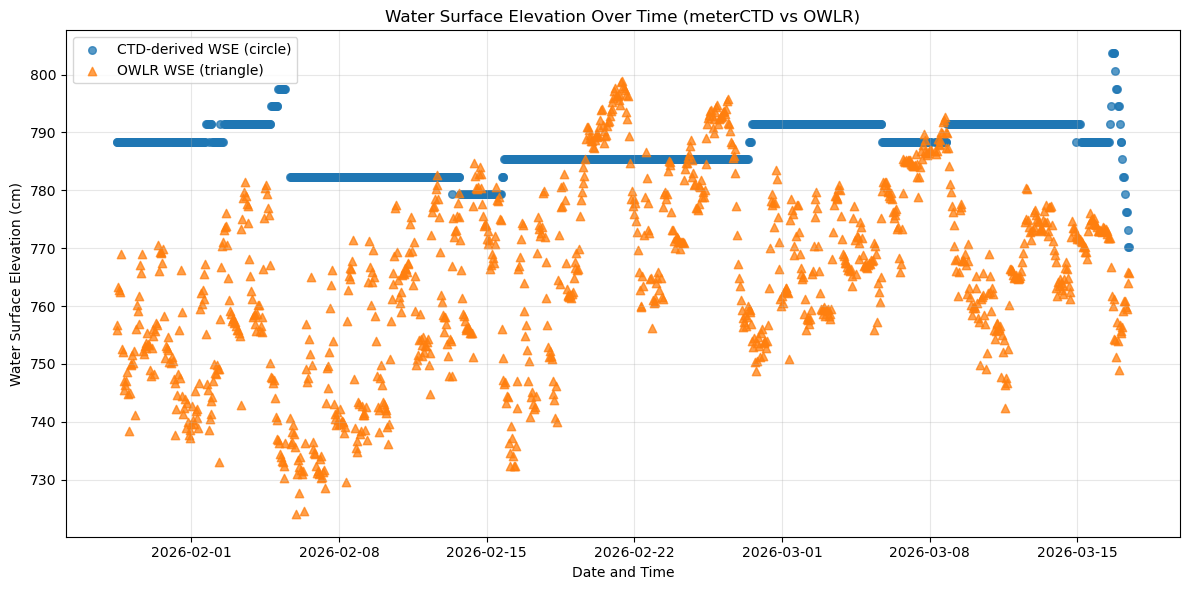

,timestamp_hour,WSE_CTD_cm,WSE_OWLR_cm
0,2026-01-28 11:00:00,788.436,755.87222
1,2026-01-28 12:00:00,788.436,756.76111
2,2026-01-28 13:00:00,788.436,763.35416
3,2026-01-28 14:00:00,788.436,762.85973
4,2026-01-28 15:00:00,788.436,762.47500


In [21]:
# File paths
wse_CTD_path = os.path.join('Data', 'wse_meterCTD_03172026.csv')
owlr_path = os.path.join('Data', 'OWLR_CMS_03172026.csv')

# Required comparison window
start_time = pd.Timestamp('2026-01-28 11:00:00')
end_time = pd.Timestamp('2026-03-17 11:00:00')

# Load CTD fluid depth (15-minute data in feet).
# This export has 5 metadata lines before the header row.
CTD_raw = pd.read_csv(wse_CTD_path, skiprows=5)
CTD_raw.columns = [str(c).strip() for c in CTD_raw.columns]

# CTD columns
CTD_time_col = CTD_raw.columns[0]
CTD_depth_col = CTD_raw.columns[1]

CTD_raw[CTD_time_col] = pd.to_datetime(CTD_raw[CTD_time_col], errors='coerce')
CTD_raw[CTD_depth_col] = pd.to_numeric(CTD_raw[CTD_depth_col], errors='coerce')

# Keep only exact hourly CTD marks (no summation)
CTD_hourly = CTD_raw[
    CTD_raw[CTD_time_col].notna()
    & (CTD_raw[CTD_time_col].dt.minute == 0)
    & (CTD_raw[CTD_time_col].dt.second == 0)
].copy()

# Apply requested window
CTD_hourly = CTD_hourly[
    (CTD_hourly[CTD_time_col] >= start_time)
    & (CTD_hourly[CTD_time_col] <= end_time)
].copy()

# Convert depth to cm and compute CTD-derived WSE (cm)
CTD_hourly['WSE_CTD_cm'] = CTD_hourly[CTD_depth_col] * 30.48 + 706.14

# Build hourly merge key
CTD_hourly['timestamp_hour'] = CTD_hourly[CTD_time_col].dt.floor('h')
CTD_hourly = CTD_hourly[['timestamp_hour', 'WSE_CTD_cm']]

# Load OWLR CMS file (WSE is the 2nd variable inside payload string in last column)
owlr_raw = pd.read_csv(owlr_path, header=None)
owlr_raw = owlr_raw.rename(columns={0: 'device_id', 1: 'timestamp', 2: 'unused_1', 3: 'data'})

owlr_raw['timestamp'] = pd.to_datetime(owlr_raw['timestamp'], errors='coerce')

# Parse payload like: "1764080734,60.36389,0,0.17, 0"
payload_parts = owlr_raw['data'].astype(str).str.split(',')
owlr_raw['OWLR_value_cm'] = pd.to_numeric(payload_parts.str[1], errors='coerce')

# Convert OWLR value to WSE using user-specified formula
owlr_raw['WSE_OWLR_cm'] = 845 - owlr_raw['OWLR_value_cm']

# Apply requested window
owlr = owlr_raw[
    owlr_raw['timestamp'].notna()
    & (owlr_raw['timestamp'] >= start_time)
    & (owlr_raw['timestamp'] <= end_time)
].copy()

# Align OWLR timestamps to hour for comparison with CTD hourly marks
owlr['timestamp_hour'] = owlr['timestamp'].dt.floor('h')
owlr = owlr[['timestamp_hour', 'WSE_OWLR_cm']].dropna()

# If multiple OWLR samples occur in one hour, use mean for that hour
owlr = owlr.groupby('timestamp_hour', as_index=False)['WSE_OWLR_cm'].mean()

# Match by hour
comparison = pd.merge(CTD_hourly, owlr, on='timestamp_hour', how='inner').dropna()
comparison = comparison.sort_values('timestamp_hour').reset_index(drop=True)

print(f'Window: {start_time} to {end_time}')
print(f'Hourly CTD points in window: {len(CTD_hourly)}')
print(f'OWLR hourly points in window: {len(owlr)}')
print(f'Matched comparison points: {len(comparison)}')

# Time-series comparison plot with different marker shapes
plt.figure(figsize=(12, 6))
plt.scatter(
    comparison['timestamp_hour'],
    comparison['WSE_CTD_cm'],
    s=30,
    marker='o',
    alpha=0.75,
    label='CTD-derived WSE (circle)'
)
plt.scatter(
    comparison['timestamp_hour'],
    comparison['WSE_OWLR_cm'],
    s=36,
    marker='^',
    alpha=0.75,
    label='OWLR WSE (triangle)'
)

plt.title('Water Surface Elevation Over Time (meterCTD vs OWLR)')
plt.xlabel('Date and Time')
plt.ylabel('Water Surface Elevation (cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

comparison.head()

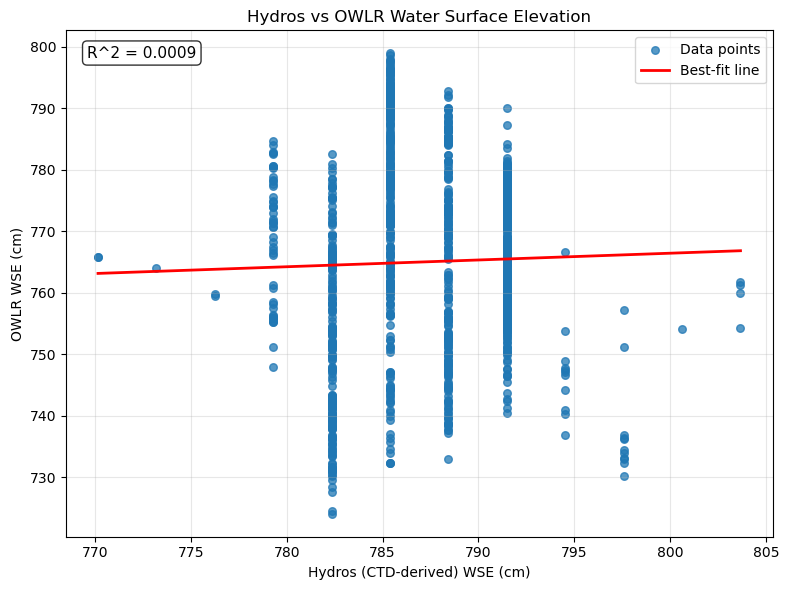

Best-fit line: y = 0.1100x + 678.4708
R^2 = 0.0009


In [24]:
# Hydros (CTD-derived) vs OWLR scatter with best-fit line and R^2
if 'comparison' not in globals() or comparison.empty:
    raise ValueError('Run Cell 2 first so comparison data is available.')

x = comparison['WSE_CTD_cm'].to_numpy()
y = comparison['WSE_OWLR_cm'].to_numpy()

# Linear best-fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

# Coefficient of determination (R^2)
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=30, alpha=0.75, marker='o', label='Data points')

x_line = np.linspace(np.min(x), np.max(x), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='red', linewidth=2, label='Best-fit line')

plt.title('Hydros vs OWLR Water Surface Elevation')
plt.xlabel('Hydros (CTD-derived) WSE (cm)')
plt.ylabel('OWLR WSE (cm)')
plt.grid(True, alpha=0.3)
plt.legend()

# Add R^2 annotation on the graph
ax = plt.gca()
ax.text(
    0.03,
    0.97,
    f'R^2 = {r2:.4f}',
    transform=ax.transAxes,
    fontsize=11,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

print(f'Best-fit line: y = {m:.4f}x + {b:.4f}')
print(f'R^2 = {r2:.4f}')